# Research Question Notebook

This notebook contains the full analysis for **RQ1** and **RQ2**, linking tumour-associated microbial taxa to food-derived microbiomes.

## Introduction

### RQ1: Survivor- vs. Deceased-Enriched Taxa
We identify microbial taxa enriched in **survivors** and **deceased** CRC patients, match them to food-associated species (**cFMD**), and evaluate statistical enrichment and **UMAP** structure.

### RQ2: Food Category Overlap
We map survival-associated taxa to **cFMD metadata**, quantify their occurrence across food categories (e.g., *dairy, fermented, meat*), and visualise their distribution.

---
*This notebook produces all outputs required to interpret RQ1 and RQ2 in the final report.*

## 1. Setup & Imports

Import core Python libraries (Pandas, NumPy, etc.) used throughout the analysis.

In [1]:
import pandas as pd
import numpy as np


### 1.1 Taxa lists for NORMAL vs TUMOR

Load precomputed taxa enrichment tables for **NORMAL** and **TUMOR** tissue.

In [2]:
df_normal = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/output/taxa_enriched_in_NORMAL.csv")
df_tumor = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/output/taxa_enriched_in_TUMOR.csv")

### 1.2 Taxa lists for survivor vs deceased

Load taxa that are enriched in colorectal cancer patients who **survived** versus those who **deceased**.

In [3]:
df_surivor = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/final_outputs/survivor_taxa_enriched.csv")
df_deceased = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/final_outputs/decased_taxa_enriched.csv")

### 1.3 Shared species table

Load `df_shared_spz`, which contains **shared species** between the patient metagenomes (TCGA) and the food metagenomes (cFMD).

In [4]:
df_shared_spz = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/output/df_clean.csv")

## 2. RQ1 – Linking shared taxa to survivor/deceased groups

In this step the shared-species table is restricted to taxa that also appear in the survivor- and deceased-enriched taxa lists.

In [5]:
col_shared = "food_species_canon"
col_other  = "taxon"

in_survivor = df_shared_spz[df_shared_spz[col_shared].isin(df_surivor[col_other])]
in_deceased  = df_shared_spz[df_shared_spz[col_shared].isin(df_deceased[col_other])]

### 2.1 Enrichment table (Δ survivor − deceased)

Load the species-level enrichment table with **Δ values** (difference in mean relative abundance: survivor minus deceased). This will be merged onto the shared taxa.

In [6]:
enricht_spz = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/output/species_relative_abundance_comparison.csv")
enricht_spz

,Unnamed: 0,mean_alive,mean_dead,delta,species_label
0,'Catharanthus roseus' aster yellows phytoplasma,0.000000,0.000000,0.000000,'Catharanthus roseus' aster yellows phytoplasma
1,Aalivirus A,0.000000,0.000000,0.000000,Aalivirus A
2,Abatino macacapox virus,0.000000,0.000240,-0.000240,Abatino macacapox virus
3,Abelson murine leukemia virus,0.000000,0.000000,0.000000,Abelson murine leukemia virus
4,Abiotrophia defectiva,0.000404,0.000506,-0.000102,Abiotrophia defectiva
...,...,...,...,...,...
11379,uncultured Erythrobacter sp.,0.000000,0.000096,-0.000096,uncultured Erythrobacter sp.
11380,uncultured Hydrogenophaga sp.,0.006352,0.012561,-0.006209,uncultured Hydrogenophaga sp.
11381,uncultured Pseudomonas sp.,0.000000,0.000000,0.000000,uncultured Pseudomonas sp.
11382,uncultured Sphingopyxis sp.,0.000046,0.000239,-0.000193,uncultured Sphingopyxis sp.


### 2.2 Canonical species names & merge with Δ

Here we:
- standardise species names into a **canonical format** (lowercase, spaces instead of underscores)
- add canonical species columns to the survivor/deceased shared taxa tables
- merge these with the enrichment table to attach a Δ value per shared taxon.

In [7]:
# 1) canonicalization function
def canonise(s):
    return (s
            .str.lower()
            .str.replace('_', ' ', regex=False)
            .str.strip())

# 2) add canonical columns
in_survivor  = in_survivor.assign(species_canon=canonise(in_survivor['food_species_canon']))
in_deceased  = in_deceased.assign(species_canon=canonise(in_deceased['food_species_canon']))
enricht_spz  = enricht_spz.assign(
    species_canon=canonise(enricht_spz['species_label']),
    delta=enricht_spz['delta']
)

# 3) merge with enrichment table
surv_enrich = in_survivor.merge(
    enricht_spz[['species_canon', 'delta']],
    on='species_canon',
    how='left'
)

dead_enrich = in_deceased.merge(
    enricht_spz[['species_canon', 'delta']],
    on='species_canon',
    how='left'
)

### 2.3 Classifying the enrichment direction

We classify whether each shared taxon is enriched in the expected group:
- `delta > 0` → enriched in **survivors**
- `delta < 0` → enriched in **deceased**

Then we count how many shared taxa per group actually match this expected direction.

In [8]:



# classify: delta>0 → enriched in alive, delta<0 → enriched in dead
surv_enrich['enriched_in_alive']   = surv_enrich['delta'] > 0
surv_enrich['enriched_in_dead']    = surv_enrich['delta'] < 0

surv_enrich['enriched_in_alive'] = surv_enrich['delta'] > 0
dead_enrich['enriched_in_dead']  = dead_enrich['delta'] < 0

# how many match their group?
n_surv_correct   = surv_enrich['enriched_in_alive'].sum()
n_deceased_correct = dead_enrich['enriched_in_dead'].sum()

In [9]:
# Summary: how many shared taxa match the expected enrichment direction?
print(f"Survivor group: {int(n_surv_correct)}/{len(surv_enrich)} shared taxa have delta > 0")
print(f"Deceased group: {int(n_deceased_correct)}/{len(dead_enrich)} shared taxa have delta < 0")
if len(surv_enrich) > 0:
    print(f"→ Fraction consistent in survivors: {n_surv_correct/len(surv_enrich):.2%}")
if len(dead_enrich) > 0:
    print(f"→ Fraction consistent in deceased: {n_deceased_correct/len(dead_enrich):.2%}")


Survivor group: 18/39 shared taxa have delta > 0
Deceased group: 27/30 shared taxa have delta < 0
→ Fraction consistent in survivors: 46.15%
→ Fraction consistent in deceased: 90.00%


### 2.4 Export of survivor-enriched shared taxa

Filter shared taxa with `delta > 0` (enriched in survivors) and export them to a CSV file for downstream interpretation.

In [10]:
surv_enriched = surv_enrich[surv_enrich["enriched_in_alive"] == True]
surv_enriched.to_csv("final_outputs/surv_enriched.csv", index= True)

Interim result for RQ1: the number of considered shared taxa decreased from 39 to 18; these 18 taxa are actually enriched in patients who survived (`delta > 0`).

### 2.5 Top 10 survivor-enriched taxa

Select the 10 shared taxa with the largest positive Δ among survivors, drop non-essential columns, display the table and save it to disk.

In [11]:
top10 = surv_enriched.nlargest(10, 'delta').drop(
    columns=['food_species_original', 'enriched_in_dead','mapped_s4_species_canon', 'mapped_s4_species', 'match_method', 'match_score', 'review', 'food_species_canon']
)
top10
top10.to_csv("final_outputs/top10_survival_enriched.csv", index= False)

### 2.6 Deceased-enriched shared taxa

Analogous to the survivor group, we filter shared taxa with `delta < 0` that are enriched in deceased patients.

In [12]:
dead_enriched = dead_enrich[dead_enrich["enriched_in_dead"] == True]
#dead_enriched.to_csv("final_outputs/dead_enriched.csv", index= False)

### 2.7 Top 10 deceased-enriched taxa

Select the 10 shared taxa with the most negative Δ among deceased patients and export them as a CSV file.

In [13]:
top10_d = dead_enriched.nlargest(10, 'delta').drop(
    columns=['food_species_original', 'mapped_s4_species_canon', 'mapped_s4_species', 'match_method', 'match_score', 'review', 'food_species_canon']
)
top10_d.to_csv("final_outputs/top10_deceased_enriched.csv", index= False)

## 3. Fisher exact test – shared vs non-shared taxa

We build a 2×2 contingency table based on the enrichment table:
- **Rows:** shared vs non-shared taxa (TCGA–cFMD)
- **Columns:** enriched in survivors vs enriched in deceased

A two-sided **Fisher exact test** is used to test whether shared taxa are systematically biased toward one patient group.

In [14]:
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------
# Fisher exact test: are shared taxa biased toward
# survivor-enriched vs deceased-enriched?
# ------------------------------------------------

# 1) Canonical set of shared TCGA–cFMD species
shared_set = canonise(df_shared_spz[col_shared]).unique()

# 2) Work on all species in the enrichment table
#    (where delta != 0 → enriched in one of the groups)
enricht_spz = enricht_spz.copy()
mask_nonzero = enricht_spz["delta"] != 0

sub = enricht_spz.loc[mask_nonzero].copy()
sub["species_canon"] = canonise(sub["species_canon"])

is_shared   = sub["species_canon"].isin(shared_set)
alive_mask  = sub["delta"] > 0   # enriched in survivors
dead_mask   = sub["delta"] < 0   # enriched in deceased

# 3) 2×2 table:
#    rows   = shared vs non-shared species
#    cols   = survivor-enriched vs deceased-enriched
a = int((is_shared   & alive_mask).sum())  # shared & survivor-enriched
b = int((is_shared   & dead_mask).sum())   # shared & deceased-enriched
c = int((~is_shared  & alive_mask).sum())  # non-shared & survivor-enriched
d = int((~is_shared  & dead_mask).sum())   # non-shared & deceased-enriched

table = np.array([[a, b],
                  [c, d]])

print("Contingency table [[shared_alive, shared_dead],[nonshared_alive, nonshared_dead]]:")
print(table)

# 4) Fisher exact test (two-sided)
or_fisher, p_raw = fisher_exact(table, alternative="two-sided")

# FDR adjustment (trivial here: only one test, so p_adj == p_raw)
p_adj = multipletests([p_raw], method="fdr_bh")[1][0]

print(f"Fisher OR (alive vs dead among shared vs non-shared): {or_fisher:.3f}")
print(f"Raw p-value : {p_raw:.4g}")
print(f"FDR-adjusted p-value: {p_adj:.4g}")

Contingency table [[shared_alive, shared_dead],[nonshared_alive, nonshared_dead]]:
[[  76  195]
 [1531 5516]]
Fisher OR (alive vs dead among shared vs non-shared): 1.404
Raw p-value : 0.01654
FDR-adjusted p-value: 0.01654


In [15]:
# Simple interpretation of the Fisher exact test result
alpha = 0.05
sig = p_adj < alpha
print("\nInterpretation:")
if sig:
    direction = (
        "Shared taxa are more associated with survivors"
        if or_fisher > 1
        else "Shared taxa are more associated with deceased"
    )
    print(f"p_adj = {p_adj:.4g} < {alpha} → significant difference. {direction} (OR = {or_fisher:.2f}).")
else:
    print(f"p_adj = {p_adj:.4g} ≥ {alpha} → no statistically significant difference between shared and non-shared taxa.")



Interpretation:
p_adj = 0.01654 < 0.05 → significant difference. Shared taxa are more associated with survivors (OR = 1.40).


## Interpreting this result: 
##### [76. 196] means shared alive and shared deseased
##### [1531 5516] means nonshared alive and nonshared deseased

##### Based on that the fishers exact test runns a two sided test

##### OR > 1 means: Among shared species, the odds of being survivor enriched are higher than among non-shared species

##### 1.4 means 40% higher odds of survivor-enriched for shared taxa

##### Short version:

##### We only tested one hypothesis, so there is only one Fisher test.

##### FDR is only needed when you correct multiple tests.
##### With one test, the correction factor is 1 — so the adjusted p-value naturally equals the raw p-value.
    




In [16]:
results_df = pd.DataFrame([{
    "shared_alive": a,
    "shared_dead": b,
    "nonshared_alive": c,
    "nonshared_dead": d,
    "odds_ratio": or_fisher,
    "p_raw": p_raw,
    "p_adj": p_adj
}])

results_df.to_csv("final_outputs/fisher_summary.csv", index=False)

## 4. UMAP of shared species in CLR space

Load the CLR-normalised species × samples matrix (`tcga_clr_combat1`) and restrict it to species that are shared between TCGA and cFMD.

In [17]:
tcga_clr_combat1 = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/Working_folder/final_outputs/tcga_clr_combat1.csv")

### 4.1 UMAP embedding & highlighting strongest taxa

In this part we:
- compute a UMAP based on CLR profiles of shared species
- colour each point by its Δ value (survivor − deceased)
- highlight and label the top-enriched species in both groups.

This helps assess whether survivor- vs deceased-enriched taxa cluster in feature space or are intermingled.

/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/combat_working/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Shared species used in UMAP: 69


/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/combat_working/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Top 5 survivor-enriched shared species:


,delta
species_canon,
cutibacterium acnes,1.023488
escherichia coli,0.759294
klebsiella pneumoniae,0.634819
enterococcus faecium,0.514076
pseudomonas putida,0.381493


Top 5 deceased-enriched shared species:


,delta
species_canon,
streptococcus oralis,-0.415307
acinetobacter junii,-0.095452
lacticaseibacillus rhamnosus,-0.083806
bifidobacterium longum,-0.069015
staphylococcus aureus,-0.064865


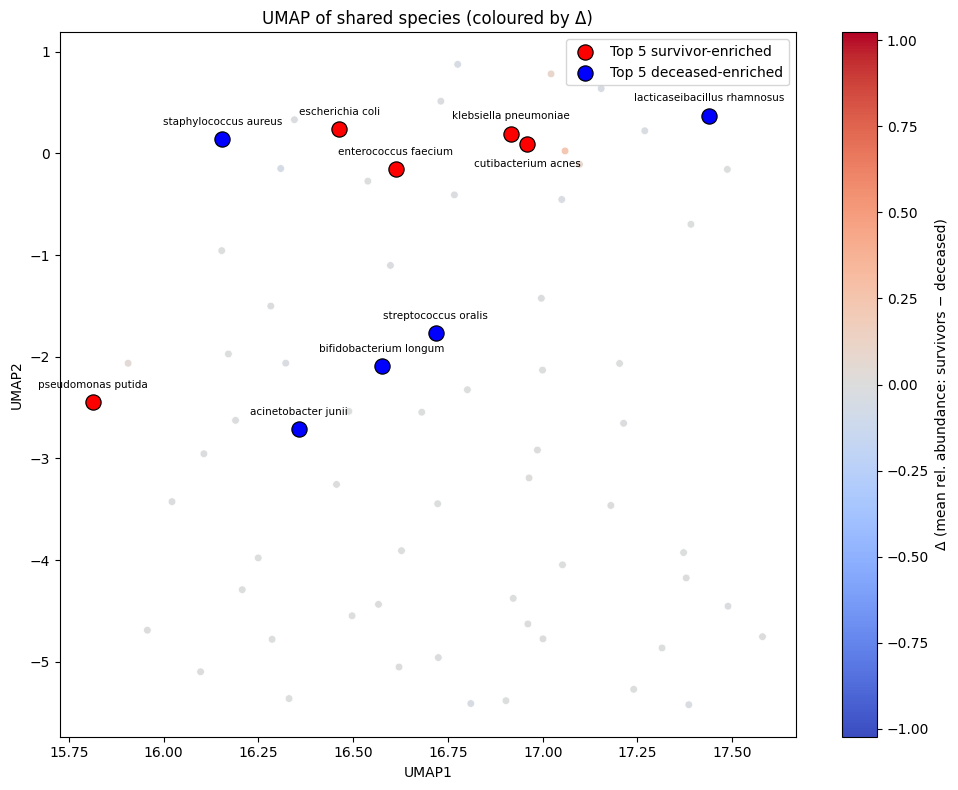

In [18]:
import umap.umap_ as umap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ----------------------------------------------------
# 1. Build species × samples CLR matrix for shared taxa
# ----------------------------------------------------
# tcga_clr_combat1: samples × species (already CLR + ComBat)
species_matrix = tcga_clr_combat1.T.copy()  # species × samples

# add canonical name index to match everything
species_matrix["species_canon"] = canonise(species_matrix.index)
species_matrix = species_matrix.set_index("species_canon")

# shared species set (TCGA–cFMD)
shared_set = canonise(df_shared_spz["food_species_canon"]).unique()

# keep only shared species
species_matrix = species_matrix.loc[species_matrix.index.intersection(shared_set)].copy()

print(f"Shared species used in UMAP: {species_matrix.shape[0]}")

# -----------------------------------------
# 2. Attach delta (survivor vs deceased) info
# -----------------------------------------
delta_tbl = (
    enricht_spz[["species_canon", "delta"]]
    .drop_duplicates(subset="species_canon")
    .set_index("species_canon")
)

species_matrix = species_matrix.join(delta_tbl, how="left")

# classify enrichment group
species_matrix["group"] = np.where(
    species_matrix["delta"] > 0, "survivor_enriched",
    np.where(species_matrix["delta"] < 0, "deceased_enriched", "neutral")
)

# ----------------------------------------------------
# 3. UMAP: species in CLR space (each dot = one species)
# ----------------------------------------------------
X = species_matrix.drop(columns=["delta", "group"])

reducer = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)
umap_coords = reducer.fit_transform(X)

species_matrix["UMAP1"] = umap_coords[:, 0]
species_matrix["UMAP2"] = umap_coords[:, 1]

# ----------------------------------------------------
# 4. Pick top enriched species (by |delta|) in each group
# ----------------------------------------------------
surv = species_matrix.query("group == 'survivor_enriched'").dropna(subset=["delta"])
dead = species_matrix.query("group == 'deceased_enriched'").dropna(subset=["delta"])

top5_surv = surv.reindex(surv["delta"].abs().sort_values(ascending=False).head(5).index)
top5_dead = dead.reindex(dead["delta"].abs().sort_values(ascending=False).head(5).index)

print("Top 5 survivor-enriched shared species:")
display(top5_surv[["delta"]].sort_values("delta", ascending=False))

print("Top 5 deceased-enriched shared species:")
display(top5_dead[["delta"]].sort_values("delta", ascending=True))

# ----------------------------------------------------
# 5. Plot UMAP with highlighted + labelled top species
#     (fixed colormap / normalization)
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# set symmetric limits around 0 for Δ
delta = species_matrix["delta"]
vmax = np.nanmax(np.abs(delta))
vmin = -vmax

cmap = plt.cm.coolwarm
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# 1) Base scatter: all shared species, coloured by Δ
base_sc = sns.scatterplot(
    data=species_matrix,
    x="UMAP1", y="UMAP2",
    hue="delta",
    palette=cmap,       # use the same cmap
    hue_norm=norm,      # and the same normalization
    alpha=1,
    s=30,
    legend=False,
    ax=ax
)

# colorbar that matches the scatter
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="Δ (mean rel. abundance: survivors − deceased)")

# highlight top enriched
sns.scatterplot(
    data=top5_surv,
    x="UMAP1", y="UMAP2",
    color="red", s=120, edgecolor="black", label="Top 5 survivor-enriched", ax=ax
)

sns.scatterplot(
    data=top5_dead,
    x="UMAP1", y="UMAP2",
    color="blue", s=120, edgecolor="black", label="Top 5 deceased-enriched", ax=ax
)

# labels (default offset upward)
for idx, row in top5_surv.iterrows():
    if idx == "cutibacterium acnes":
        # special case: move DOWN instead of up
        plt.text(
            row["UMAP1"],
            row["UMAP2"] - 0.15,
            idx,
            fontsize=7.5,
            ha="center",
            va="top",
            color="black",
        )
    else:
        # normal behaviour for all others (shift upward)
        plt.text(
            row["UMAP1"],
            row["UMAP2"] + 0.12,
            idx,
            fontsize=7.5,
            ha="center",
            va="bottom",
            color="black",
        )

for idx, row in top5_dead.iterrows():
    plt.text(
        row["UMAP1"],
        row["UMAP2"] + 0.12,
        idx,
        fontsize=7.5,
        ha="center",
        va="bottom",
        color="black",
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of shared species (coloured by Δ)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. RQ2 – Mapping target species to food MAGs

For RQ2, we investigate in which **food categories** the target taxa from RQ1 occur, using the cFMD MAG list and its metadata.

### RQ2

### 5.1 Load cFMD MAG list

Load the list of MAGs from the cFMD dataset, containing per-sample species assignments for food microbiomes.

In [19]:
mags = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/cFMD/cFMD_mags_list.tsv", sep="\t")

### 5.2 Load cFMD metadata

Load metadata for cFMD samples, including **food category** and whether the food is fermented or non-fermented.

In [20]:
meta = pd.read_csv("/Users/laurinseelig/Desktop/ZHAW Semester 5/PA2/Data Set/Data/cFMD/cFMD_metadata.tsv", sep="\t")

### 5.3 Cleaning species names & matching target taxa

Define a robust canonicalisation function for MAG species names (replace underscores, lowercasing, trimming noise) and apply it. Then match these cleaned names to the target taxa (survivor- and deceased-enriched species) from RQ1 and merge them with the cFMD metadata.

In [21]:
import pandas as pd
import re

# 1. CORRECTED CANONICALIZATION FUNCTION
def clean_species_name(name):
    """
    Standardizes species names: replaces underscores with spaces, lowercase, etc.
    """
    if pd.isna(name):
        return ""
    # Convert to string
    name = str(name)
    
    # CRITICAL FIX: Replace underscores with spaces FIRST
    name = name.replace('_', ' ')
    
    # Lowercase
    name = name.lower()
    
    # Remove common taxonomic noise
    name = re.sub(r'subsp\.|strain|str\.|biovar|serovar|pv\.', '', name)
    
    # Remove non-alphabet characters (keep spaces)
    name = re.sub(r'[^a-z ]', '', name)
    
    # Collapse multiple spaces to single space and trim
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

# 2. DEFINE TARGET BACTERIA (From RQ1)
survivor_targets = [
    "cutibacterium acnes", "escherichia coli", "klebsiella pneumoniae",
    "pseudomonas putida", "klebsiella michiganensis", "stenotrophomonas maltophilia",
    "enterococcus faecalis", "xanthomonas campestris", "lactococcus lactis",
    "lactobacillus gasseri"
]

deceased_targets = [
    "mammaliicoccus lentus", "pantoea agglomerans", "aeromonas caviae",
    "bifidobacterium longum", "lacticaseibacillus paracasei", "streptococcus mutans",
    "moraxella osloensis", "enterobacter asburiae", "lactococcus garvieae",
    "curtobacterium citreum"
]

# 3. PREPARE THE DATASETS
# Apply the NEW canonicalization to the MAGs species column
mags['species_clean'] = mags['species'].apply(clean_species_name)

# Tag Association
def get_association(name):
    if name in survivor_targets: return 'Survivor-Enriched'
    if name in deceased_targets: return 'Deceased-Enriched'
    return 'Other'

# Create a filtered dataframe containing ONLY the target bacteria
target_mags = mags[mags['species_clean'].isin(survivor_targets + deceased_targets)].copy()
target_mags['Association'] = target_mags['species_clean'].apply(get_association)

# Check if we have matches now (Diagnostic)
print(f"Found {len(target_mags)} matching rows after cleaning.")

# 4. MERGE DATASETS
# Join MAGs with Metadata on 'sample_id'
merged_df = pd.merge(
    target_mags[['sample_id', 'species_clean', 'Association']], 
    meta[['sample_id', 'category', 'fermented/non-fermented']], 
    on='sample_id', 
    how='inner'
)

# 5. GENERATE SUMMARY STATISTICS
# Count occurrences of each bacteria in different food categories
summary_counts = merged_df.groupby(
    ['Association', 'species_clean', 'category', 'fermented/non-fermented']
).size().reset_index(name='Count')

# Sort results
summary_counts = summary_counts.sort_values(by=['Association', 'Count'], ascending=[False, False])

# 6. DISPLAY RESULTS
print("\n--- ANALYSIS RESULT: Presence of RQ1 Bacteria in Food ---")
print(summary_counts.head(20))

# Optional: Pivot table view
if not summary_counts.empty:
    pivot_view = merged_df.pivot_table(
        index=['Association', 'species_clean'], 
        columns='category', 
        values='sample_id', 
        aggfunc='count', 
        fill_value=0
    )
    print("\n--- MATRIX VIEW (Bacteria vs Food Category) ---")
    print(pivot_view)
else:
    print("Warning: Still no matches found. Please check spelling in target lists.")

Found 1518 matching rows after cleaning.

--- ANALYSIS RESULT: Presence of RQ1 Bacteria in Food ---
          Association                 species_clean  \
42  Survivor-Enriched            lactococcus lactis   
31  Survivor-Enriched              escherichia coli   
28  Survivor-Enriched         enterococcus faecalis   
43  Survivor-Enriched            lactococcus lactis   
37  Survivor-Enriched         klebsiella pneumoniae   
48  Survivor-Enriched            lactococcus lactis   
32  Survivor-Enriched              escherichia coli   
33  Survivor-Enriched              escherichia coli   
52  Survivor-Enriched            pseudomonas putida   
54  Survivor-Enriched  stenotrophomonas maltophilia   
46  Survivor-Enriched            lactococcus lactis   
30  Survivor-Enriched         enterococcus faecalis   
40  Survivor-Enriched         lactobacillus gasseri   
45  Survivor-Enriched            lactococcus lactis   
35  Survivor-Enriched      klebsiella michiganensis   
44  Survivor-Enriche

In [22]:
# Numeric summary of the bacteria × food × association counts
if 'summary_counts' in globals() and not summary_counts.empty:
    print(
        "Number of combinations (Association × species × category × fermentation):",
        len(summary_counts),
    )
    print("Distribution of 'Count' per combination:")
    print(summary_counts['Count'].describe())
else:
    print("summary_counts is empty – cannot provide a numeric overview.")


Number of combinations (Association × species × category × fermentation): 57
Distribution of 'Count' per combination:
count     57.000000
mean      26.631579
std      110.774970
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max      751.000000
Name: Count, dtype: float64


### 5.4 Overview of most frequent bacteria–food combinations

Show the most frequent combinations of association, species, food category and fermentation status to get an initial overview of the distribution.

In [23]:
# View the top food sources for the most frequent bacteria
print(summary_counts.head(15)[['Association', 'species_clean', 'category', 'fermented/non-fermented', 'Count']])

          Association                 species_clean  \
42  Survivor-Enriched            lactococcus lactis   
31  Survivor-Enriched              escherichia coli   
28  Survivor-Enriched         enterococcus faecalis   
43  Survivor-Enriched            lactococcus lactis   
37  Survivor-Enriched         klebsiella pneumoniae   
48  Survivor-Enriched            lactococcus lactis   
32  Survivor-Enriched              escherichia coli   
33  Survivor-Enriched              escherichia coli   
52  Survivor-Enriched            pseudomonas putida   
54  Survivor-Enriched  stenotrophomonas maltophilia   
46  Survivor-Enriched            lactococcus lactis   
30  Survivor-Enriched         enterococcus faecalis   
40  Survivor-Enriched         lactobacillus gasseri   
45  Survivor-Enriched            lactococcus lactis   
35  Survivor-Enriched      klebsiella michiganensis   

                           category fermented/non-fermented  Count  
42                            dairy               

### 5.5 Visualising food associations

Produce two plots:
1. A **heatmap** (bacteria × food category, log-scaled) summarising counts.
2. A **stacked bar plot** per food category split by survivor- vs deceased-enriched taxa.

This helps identify categories that are more frequently associated with potentially beneficial or harmful microbial profiles.

Generated: rq2_heatmap.png
Generated: rq2_stacked_bar.png


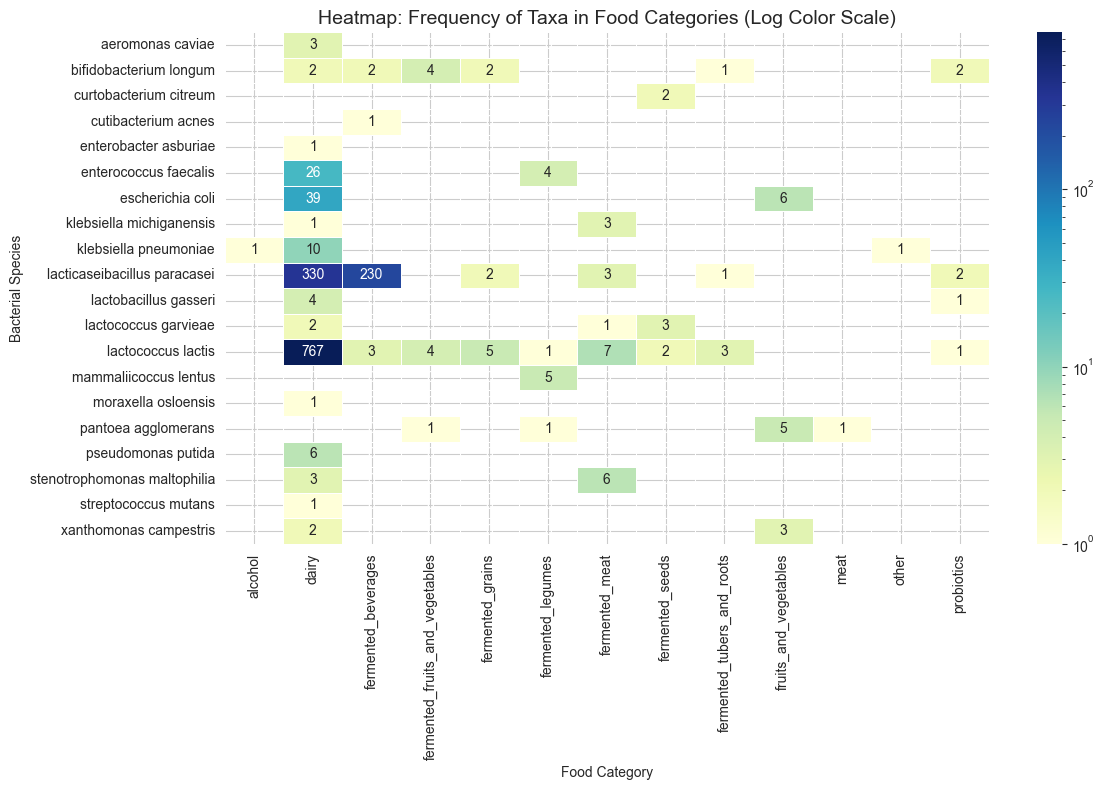

<Figure size 1200x600 with 0 Axes>

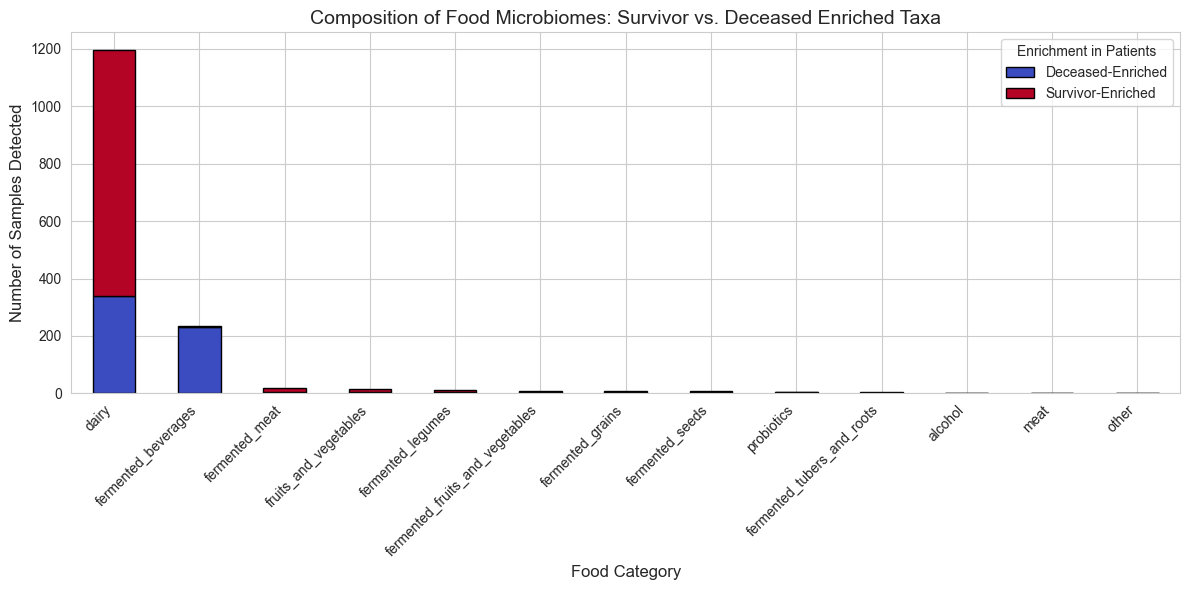

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set global style
sns.set_style("whitegrid")

# -------------------------------------------------------
# PLOT OPTION 1: Heatmap (Bacteria vs. Food Category)
# -------------------------------------------------------
# Best for: Seeing the "big picture" of where every bacteria appears.
# -------------------------------------------------------
plt.figure(figsize=(12, 8))

# Create a pivot table: Rows=Bacteria, Cols=Food Category, Values=Count
heatmap_data = merged_df.pivot_table(
    index='species_clean', 
    columns='category', 
    values='sample_id', 
    aggfunc='count', 
    fill_value=0
)

# We use a Log-Scale Color (LogNorm) because L. lactis (751) is so huge 
# it would otherwise make everything else look invisible.
from matplotlib.colors import LogNorm

sns.heatmap(
    heatmap_data, 
    annot=True, 
    fmt="d", 
    cmap="YlGnBu", 
    norm=LogNorm(),  # Critical for handling the 751 outlier
    linewidths=.5
)

plt.title('Heatmap: Frequency of Taxa in Food Categories (Log Color Scale)', fontsize=14)
plt.ylabel('Bacterial Species')
plt.xlabel('Food Category')
plt.tight_layout()
plt.savefig('rq2_heatmap.png', dpi=300)
print("Generated: rq2_heatmap.png")

# -------------------------------------------------------
# PLOT OPTION 2: Stacked Bar Chart (Survivor vs Deceased Contribution)
# -------------------------------------------------------
# Best for: Comparing which Food Categories are "safest" or "riskiest".
# -------------------------------------------------------
plt.figure(figsize=(12, 6))

# Count Association types per Food Category
category_counts = merged_df.groupby(['category', 'Association']).size().unstack(fill_value=0)

# Sort by total count so the big categories are on the left
category_counts['Total'] = category_counts.sum(axis=1)
category_counts = category_counts.sort_values('Total', ascending=False).drop(columns='Total')

# Plot
category_counts.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 6), 
    colormap='coolwarm', 
    edgecolor='black'
)

plt.title('Composition of Food Microbiomes: Survivor vs. Deceased Enriched Taxa', fontsize=14)
plt.ylabel('Number of Samples Detected', fontsize=12)
plt.xlabel('Food Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Enrichment in Patients')
plt.tight_layout()
plt.savefig('rq2_stacked_bar.png', dpi=300)
print("Generated: rq2_stacked_bar.png")